**Import Libraries and Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
import lightgbm as lgb
from xgboost import XGBClassifier

In [ ]:
!pip install category_encoders
import category_encoders as ce

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.8 MB/s eta 0:00:00


In [ ]:
application_train = pd.read_csv("/content/application_train.csv")
bureau = pd.read_csv("/content/bureau.csv")
bureau_balance = pd.read_csv("/content/bureau_balance.csv")
credit_card_balance = pd.read_csv("/content/credit_card_balance.csv")
installments_payments = pd.read_csv("/content/installments_payments.csv")
pos_cash_balance = pd.read_csv("/content/POS_CASH_balance.csv")
previous_application = pd.read_csv("/content/previous_application.csv")

**Basic Checks**

In [ ]:
application_train.shape

(307511, 122)

In [ ]:
application_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [ ]:
application_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [ ]:
application_train.head(2)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
application_train.tail(2)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [ ]:
file_name = ['bureau', 'bureau_balance', 'credit_card_balance',
             'installments_payments', 'pos_cash_balance',
             'previous_application']
files = [bureau, bureau_balance, credit_card_balance,
             installments_payments, pos_cash_balance,
             previous_application]
for i, file in enumerate(files):
  print(file_name[i])
  print("shape:", file.shape)

bureau
shape: (1716428, 17)
bureau_balance
shape: (27299925, 3)
credit_card_balance
shape: (3840312, 23)
installments_payments
shape: (4636346, 8)
pos_cash_balance
shape: (5953056, 8)
previous_application
shape: (976590, 37)


In [ ]:
application_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
application_train['TARGET'].value_counts()

,count
TARGET,
0,282686
1,24825


* Dependent variable--'Target' is not balanced, so need to apply abalance techniques

**Univariate and Bivariate Analysis**

<Axes: xlabel='CODE_GENDER', ylabel='count'>

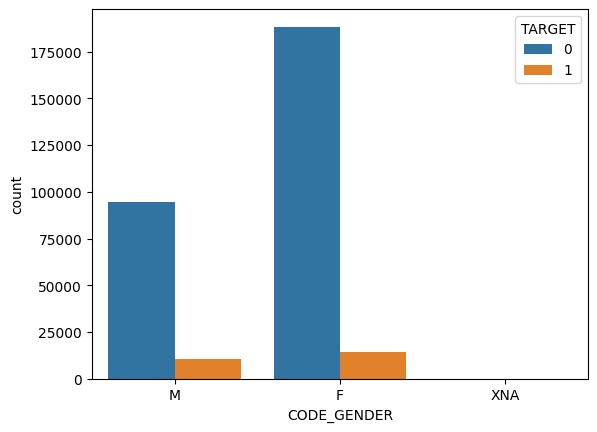

In [ ]:
sns.countplot(data = application_train, x='CODE_GENDER', hue = 'TARGET')

* Female counts are higher in count as well as non-defaulted count

In [ ]:
application_train['AGE'] = application_train['DAYS_BIRTH']/-365

<Axes: xlabel='TARGET', ylabel='AGE'>

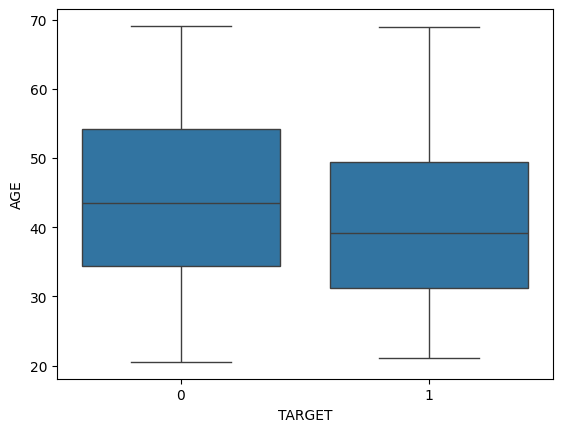

In [ ]:
sns.boxplot(x='TARGET', y='AGE', data=application_train)

* The Days_Birth is changed into Age (divided by -365)
* This shows the non-defaulted and defaulted customer's and their range of age.

In [ ]:
application_train['DAYS_EMPLOYED']

,DAYS_EMPLOYED
0,-637
1,-1188
2,-225
3,-3039
4,-3038
...,...
307506,-236
307507,365243
307508,-7921
307509,-4786


In [ ]:
application_train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

/tmp/ipykernel_12742/3570382398.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  application_train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)


In [ ]:
application_train['YEARS_EMPLOYED'] = application_train['DAYS_EMPLOYED']/-365

* Days employed is changed into years employed(divided by (-365) to get employed years)

In [ ]:
application_train = application_train.drop(['DAYS_EMPLOYED', 'DAYS_BIRTH'], axis = 1)

<Axes: xlabel='YEARS_EMPLOYED', ylabel='Count'>

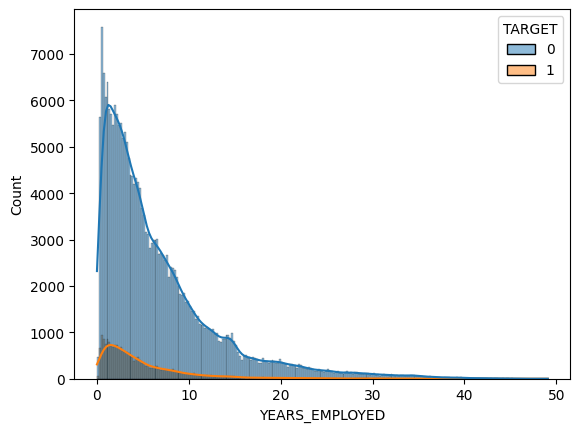

In [ ]:
sns.histplot(x='YEARS_EMPLOYED', data=application_train,hue='TARGET', kde=True)

In [ ]:
application_train['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Working,158774
Commercial associate,71617
Pensioner,55362
State servant,21703
Unemployed,22
Student,18
Businessman,10
Maternity leave,5


<Axes: xlabel='count', ylabel='NAME_INCOME_TYPE'>

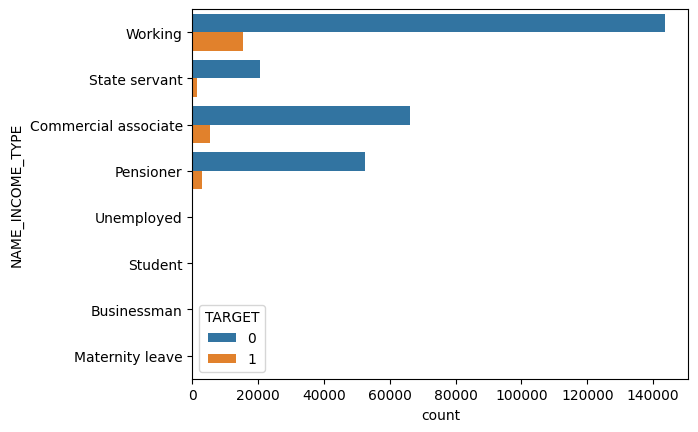

In [ ]:
sns.countplot(data=application_train, y='NAME_INCOME_TYPE', hue = 'TARGET')

* Working Professionals get non-defaulted easily when compared to others

Text(0.5, 1.0, 'Income Vs Credit')

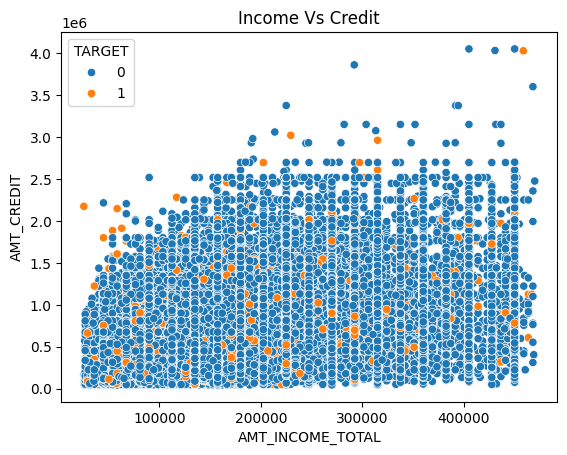

In [ ]:
income_percentile_99 = application_train['AMT_INCOME_TOTAL'].quantile(0.99)
app_train_scatter = application_train[application_train['AMT_INCOME_TOTAL']<income_percentile_99]
sns.scatterplot(x = 'AMT_INCOME_TOTAL', y = 'AMT_CREDIT', data = app_train_scatter, hue = 'TARGET')
plt.title('Income Vs Credit')
# Handling the Outliers

<Axes: xlabel='AMT_ANNUITY', ylabel='Count'>

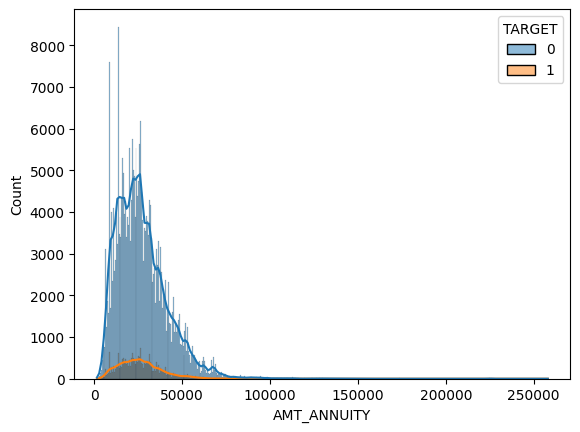

In [ ]:
sns.histplot(x='AMT_ANNUITY', data=application_train,hue='TARGET', kde=True)

In [ ]:
bureau.head(2)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN


In [ ]:
bureau_balance.head(2)

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C


* Here, Status is a categorical feature.

**Feature Engineering**

In [ ]:
application_train.duplicated().sum()

np.int64(0)

In [ ]:
bu_bal_status = pd.get_dummies(bureau_balance['STATUS'], prefix = 'STATUS')
bu_bal_com = pd.concat([bureau_balance[['SK_ID_BUREAU']], bu_bal_status], axis = 1)
bu_bal_status_agg = bu_bal_com.groupby('SK_ID_BUREAU').sum()
bu_bal_months = bureau_balance.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].agg(['mean'])
bu_bal = bu_bal_months.merge(bu_bal_status_agg, on = 'SK_ID_BUREAU', how = 'left')

In [ ]:
bureau_bureau_bal = bureau.merge(bu_bal, on = 'SK_ID_BUREAU', how = 'left')

In [ ]:
num_col = bureau_bureau_bal.select_dtypes(exclude = 'O').columns

In [ ]:
bureau_agg = bureau_bureau_bal.groupby('SK_ID_CURR')[num_col].agg(['mean','sum'])

In [ ]:
bureau_agg.columns = ['_'.join(col).strip() for col in bureau_agg.columns.values]
application_train = application_train.merge(bureau_agg, on="SK_ID_CURR", how='left')

In [ ]:
numeric_col_prev = previous_application.select_dtypes(exclude = 'O').columns
prev_agg = previous_application.groupby('SK_ID_CURR')[numeric_col_prev].agg(['mean','sum'])
prev_agg.columns = ['_'.join(col).strip() for col in prev_agg.columns.values]
application_train = application_train.merge(prev_agg, on = 'SK_ID_CURR', how = 'left')

In [ ]:
numeric_col_poscash = pos_cash_balance.select_dtypes(exclude = 'O').columns
posh_cash_agg = pos_cash_balance.groupby('SK_ID_CURR')[numeric_col_poscash].agg(['mean', 'sum'])
posh_cash_agg.columns = ['_'.join(col).strip() for col in posh_cash_agg.columns.values]
application_train = application_train.merge(posh_cash_agg, on = 'SK_ID_CURR', how = 'left')

In [ ]:
numeric_col_ins = installments_payments.select_dtypes(exclude = 'O').columns
numeric_col_ins = numeric_col_ins.drop('SK_ID_CURR')
ins_agg = installments_payments.groupby('SK_ID_CURR')[numeric_col_ins].agg(['mean', 'sum'])
ins_agg.columns = ['_'.join(col).strip() for col in ins_agg.columns.values]
application_train = application_train.merge(ins_agg, on ='SK_ID_CURR', how = 'left')

In [ ]:
numeric_col_cred = credit_card_balance.select_dtypes(exclude = 'O').columns
numeric_col_cred = numeric_col_cred.drop('SK_ID_CURR')
cred_agg = credit_card_balance.groupby('SK_ID_CURR')[numeric_col_cred].agg(['mean', 'sum'])
cred_agg.columns = ['_'.join(col).strip() for col in cred_agg.columns.values]
application_train = application_train.merge(cred_agg, on = 'SK_ID_CURR', how = 'left', suffixes=('_from_other_aggs', '_from_credit_card_agg'))

In [ ]:
application_train.shape

(307511, 280)

In [ ]:
application_train.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
CNT_INSTALMENT_MATURE_CUM_sum,220931
SK_DPD_mean_from_credit_card_agg,220931
SK_DPD_sum_from_credit_card_agg,220931
SK_DPD_DEF_mean_from_credit_card_agg,220931


In [ ]:
missing_col = application_train.isnull().mean()*100
missing_col = missing_col.sort_values(ascending = False)
print(missing_col)

RATE_INTEREST_PRIVILEGED_mean      99.493351
RATE_INTEREST_PRIMARY_mean         99.493351
AMT_PAYMENT_CURRENT_mean           80.246885
AMT_DRAWINGS_OTHER_CURRENT_mean    80.220870
CNT_DRAWINGS_ATM_CURRENT_mean      80.220870
                                     ...    
REG_CITY_NOT_LIVE_CITY              0.000000
CODE_GENDER                         0.000000
NAME_CONTRACT_TYPE                  0.000000
TARGET                              0.000000
SK_ID_CURR                          0.000000
Length: 280, dtype: float64


In [ ]:
len(missing_col[missing_col>50])

97

In [ ]:
col_drop = missing_col[missing_col>50].index.to_list()

In [ ]:
col_drop

['RATE_INTEREST_PRIVILEGED_mean',
 'RATE_INTEREST_PRIMARY_mean',
 'AMT_PAYMENT_CURRENT_mean',
 'AMT_DRAWINGS_OTHER_CURRENT_mean',
 'CNT_DRAWINGS_ATM_CURRENT_mean',
 'CNT_DRAWINGS_POS_CURRENT_mean',
 'AMT_DRAWINGS_POS_CURRENT_mean',
 'CNT_DRAWINGS_OTHER_CURRENT_mean',
 'AMT_DRAWINGS_ATM_CURRENT_mean',
 'AMT_ANNUITY_mean_x',
 'SK_DPD_mean_from_credit_card_agg',
 'SK_DPD_sum_from_credit_card_agg',
 'AMT_DRAWINGS_POS_CURRENT_sum',
 'AMT_INST_MIN_REGULARITY_mean',
 'SK_DPD_DEF_mean_from_credit_card_agg',
 'SK_DPD_DEF_sum_from_credit_card_agg',
 'AMT_PAYMENT_CURRENT_sum',
 'AMT_INST_MIN_REGULARITY_sum',
 'AMT_PAYMENT_TOTAL_CURRENT_mean',
 'AMT_PAYMENT_TOTAL_CURRENT_sum',
 'MONTHS_BALANCE_sum_from_credit_card_agg',
 'AMT_BALANCE_sum',
 'AMT_BALANCE_mean',
 'MONTHS_BALANCE_mean_from_credit_card_agg',
 'SK_ID_PREV_sum_from_credit_card_agg',
 'SK_ID_PREV_mean_from_credit_card_agg',
 'AMT_TOTAL_RECEIVABLE_mean',
 'CNT_DRAWINGS_POS_CURRENT_sum',
 'CNT_INSTALMENT_MATURE_CUM_sum',
 'CNT_DRAWINGS_CUR

In [ ]:
col_drop.remove('EXT_SOURCE_1')

In [ ]:
len(col_drop)

96

In [ ]:
application_train = application_train.drop(columns = col_drop)

* Columns with more than 50% missing values are dropped but kept 'EXT_SOURCE_1' because of its importance

In [ ]:
num_col_app = application_train.select_dtypes(exclude = 'O').columns
cat_col_app = application_train.select_dtypes(include = 'O').columns

In [ ]:
for col in num_col_app:
  application_train[col] = application_train[col].fillna(application_train[col].median())
for col in cat_col_app:
  application_train[col] = application_train[col].fillna(application_train[col].mode()[0])

In [ ]:
application_train.isnull().sum().sum()

np.int64(0)

In [ ]:
application_train['CREDIT_INCOME_RATIO'] = application_train['AMT_CREDIT']/application_train['AMT_INCOME_TOTAL']
application_train['ANNUITY_INCOME_RATIO'] = application_train['AMT_ANNUITY']/application_train['AMT_INCOME_TOTAL']
application_train['CREDIT_GOODS_RATIO'] = application_train['AMT_CREDIT']/application_train['AMT_GOODS_PRICE']

/tmp/ipykernel_12742/4106426242.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_train['CREDIT_INCOME_RATIO'] = application_train['AMT_CREDIT']/application_train['AMT_INCOME_TOTAL']
/tmp/ipykernel_12742/4106426242.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_train['ANNUITY_INCOME_RATIO'] = application_train['AMT_ANNUITY']/application_train['AMT_INCOME_TOTAL']
/tmp/ipykernel_12742/4106426242.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.in

**Scaling and Encoding**

In [ ]:
ohe_cols = [col for col in cat_col_app if application_train[col].nunique()<=10]
tar_cols = [col for col in cat_col_app if application_train[col].nunique()>10]
num_col_app = num_col_app.drop('TARGET')
log_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
for col in log_cols:
  application_train[col] = np.log1p(application_train[col])

In [ ]:
ohe_pipeline = Pipeline(steps = [('ohe', OneHotEncoder())])
target_pipeline = Pipeline(steps = [('target', ce.TargetEncoder(cols = tar_cols))])
scaling_pipeline = Pipeline(steps= [('scaler', StandardScaler())])
preprocessor = ColumnTransformer(
    transformers = [('num', scaling_pipeline, num_col_app),
                    ('ohe', ohe_pipeline, ohe_cols),
                    ('target', target_pipeline, tar_cols)]
)


In [ ]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL',
       ...
       'NUM_INSTALMENT_NUMBER_mean', 'NUM_INSTALMENT_NUMBER_sum',
       'DAYS_INSTALMENT_mean', 'DA...
                                 ['NAME_CONTRACT_TYPE', 'CODE_GENDER',
                                  'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
                                  'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
                                  'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
                                  'NAME_HOUSING_TYPE',
                                  'WEEKDAY_APPR_PROCESS_START',
                                  'EMERGENCYSTATE_MODE']),
                                ('target',
                                 Pipeline(steps=[('target',
                                                  TargetEncoder(cols=['OCCUPATION_TYPE',
                                                                      'ORGANIZATION_TYPE']))]),
                                 ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE'])])

In [ ]:
processed_data = preprocessor.fit_transform(application_train, application_train['TARGET'])

In [ ]:
application_train.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'DAYS_INSTALMENT_sum', 'DAYS_ENTRY_PAYMENT_mean',
       'DAYS_ENTRY_PAYMENT_sum', 'AMT_INSTALMENT_mean', 'AMT_INSTALMENT_sum',
       'AMT_PAYMENT_mean', 'AMT_PAYMENT_sum', 'CREDIT_INCOME_RATIO',
       'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO'],
      dtype='object', length=187)

In [ ]:
app_train = pd.DataFrame(processed_data, columns = preprocessor.get_feature_names_out())

In [ ]:
app_train[app_train.corr()>0.8]

,num__SK_ID_CURR,num__CNT_CHILDREN,num__AMT_INCOME_TOTAL,num__AMT_CREDIT,num__AMT_ANNUITY,num__AMT_GOODS_PRICE,num__REGION_POPULATION_RELATIVE,num__DAYS_REGISTRATION,num__DAYS_ID_PUBLISH,num__FLAG_MOBIL,...,ohe__WEEKDAY_APPR_PROCESS_START_MONDAY,ohe__WEEKDAY_APPR_PROCESS_START_SATURDAY,ohe__WEEKDAY_APPR_PROCESS_START_SUNDAY,ohe__WEEKDAY_APPR_PROCESS_START_THURSDAY,ohe__WEEKDAY_APPR_PROCESS_START_TUESDAY,ohe__WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ohe__EMERGENCYSTATE_MODE_No,ohe__EMERGENCYSTATE_MODE_Yes,target__OCCUPATION_TYPE,target__ORGANIZATION_TYPE
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
app_train

,num__SK_ID_CURR,num__CNT_CHILDREN,num__AMT_INCOME_TOTAL,num__AMT_CREDIT,num__AMT_ANNUITY,num__AMT_GOODS_PRICE,num__REGION_POPULATION_RELATIVE,num__DAYS_REGISTRATION,num__DAYS_ID_PUBLISH,num__FLAG_MOBIL,...,ohe__WEEKDAY_APPR_PROCESS_START_MONDAY,ohe__WEEKDAY_APPR_PROCESS_START_SATURDAY,ohe__WEEKDAY_APPR_PROCESS_START_SUNDAY,ohe__WEEKDAY_APPR_PROCESS_START_THURSDAY,ohe__WEEKDAY_APPR_PROCESS_START_TUESDAY,ohe__WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ohe__EMERGENCYSTATE_MODE_No,ohe__EMERGENCYSTATE_MODE_Yes,target__OCCUPATION_TYPE,target__ORGANIZATION_TYPE
0,-1.733423,-0.577538,0.632545,-0.216063,0.085996,-0.268450,-0.149452,0.379837,0.579154,0.001803,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.079933,0.092996
1,-1.733413,-0.577538,1.220963,1.402080,0.760647,1.365707,-1.252750,1.078697,1.790855,0.001803,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.063040,0.059148
2,-1.733403,-0.577538,-1.614519,-1.757668,-2.290342,-1.604457,-0.783451,0.206116,0.306869,0.001803,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.079933,0.069781
3,-1.733384,-0.577538,-0.196782,-0.583286,0.422819,-0.502027,-0.928991,-1.375829,0.369143,0.001803,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.079933,0.092996
4,-1.733374,-0.577538,-0.412283,0.108957,-0.137332,0.262158,0.563570,0.191639,-0.307263,0.001803,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.063040,0.058856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,1.732372,-0.577538,0.118513,-0.870063,0.286529,-0.890216,0.845396,-0.984955,0.670578,0.001803,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.096318,0.066032
307507,1.732381,-0.577538,-1.482515,-0.790830,-1.236202,-0.890216,0.310593,0.169782,-0.725959,0.001803,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.079933,0.053996
307508,1.732391,-0.577538,0.059223,0.498188,0.440780,0.445794,-1.147120,-0.497002,-1.428203,0.001803,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.062140,0.059148
307509,1.732401,-0.577538,0.286721,-0.347540,-0.282012,-0.399923,-1.124635,0.688107,1.366859,0.001803,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.079933,0.081384


**Model Building and Evaluation**

In [ ]:
x = app_train
y = application_train['TARGET']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.80, random_state = 42)

**LogisticRegression Model**

In [ ]:
model_lr = LogisticRegression(max_iter = 500, class_weight = 'balanced')
model_lr

LogisticRegression(class_weight='balanced', max_iter=500)

In [ ]:
model_lr.fit(x_train, y_train)
y_predict = model_lr.predict(x_test)

In [ ]:
print("ROC_AUC_SCORE", roc_auc_score(y_test, y_predict))

ROC_AUC_SCORE 0.6938804611364524


**RandomForestClasssifier Model**

In [ ]:
model_rfc = RandomForestClassifier(n_estimators = 300, max_depth = 5,
                                   class_weight = 'balanced', random_state = 42,
                                   n_jobs = -1)
model_rfc

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [ ]:
model_rfc.fit(x_train, y_train)
y_predict = model_rfc.predict(x_test)
print("ROC_AUC_SCORE", roc_auc_score(y_test, y_predict))

ROC_AUC_SCORE 0.668210938473444


**XGBoost Model**

In [ ]:
neg = (y_train==0).sum()
pos = (y_train==1).sum()
scale_pos_weight = neg/pos
scale_pos_weight

np.float64(11.377138257194607)

In [ ]:
model_xgb = XGBClassifier(n_estimators = 300, learning_rate = 0.03,
                          max_depth = 5, scale_pos_weight = scale_pos_weight,
                          eval_metric = 'auc', random_state = 42)
model_xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
model_xgb.fit(x_train, y_train)
y_predict = model_xgb.predict(x_test)
print("ROC_AUC_SCORE", roc_auc_score(y_test, y_predict))

ROC_AUC_SCORE 0.6982345896242961


**LightGBM Model**

In [ ]:
model_lightgbm = lgb.LGBMClassifier(n_estimators = 500, learning_rate = 0.03,
                                    num_leaves = 15, class_weight = 'balanced', random_state = 42)
model_lightgbm

LGBMClassifier(class_weight='balanced', learning_rate=0.03, n_estimators=500,
               num_leaves=15, random_state=42)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV


In [ ]:
import re

# Clean column names for LightGBM more robustly
x_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '', col) for col in x_train.columns]
x_test.columns = [re.sub(r'[^A-Za-z0-9_]+', '', col) for col in x_test.columns]

model_lightgbm.fit(x_train, y_train)
y_predict = model_lightgbm.predict(x_test)
print("ROC_AUC_SCORE", roc_auc_score(y_test, y_predict))

[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.235393 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26982
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 211
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
ROC_AUC_SCORE 0.7005493752439969


**Adaboost Classifier Model**

In [ ]:
model_ada = AdaBoostClassifier(n_estimators = 300, learning_rate = 0.03, random_state = 42)
model_ada

AdaBoostClassifier(learning_rate=0.03, n_estimators=300, random_state=42)

In [ ]:
model_ada.fit(x_train, y_train)
y_predict  = model_ada.predict(x_test)
print("ROC_AUC_SCORE", roc_auc_score(y_test, y_predict))

ROC_AUC_SCORE 0.5


**GradientBoosting Classifier**

In [ ]:
model_gbc = GradientBoostingClassifier(n_estimators = 300, learning_rate = 0.03, max_depth = 5, random_state = 42)
model_gbc

GradientBoostingClassifier(learning_rate=0.03, max_depth=5, n_estimators=300,
                           random_state=42)

In [ ]:
model_gbc.fit(x_train, y_train)
y_predict = model_gbc.predict(x_test)
print("ROC_AUC_SCORE", roc_auc_score(y_test, y_predict))

**HyperParameterTuning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
xgb = XGBClassifier(
    objective = 'binary:logistic',
    eval_metric = 'auc',
    use_label_encoder = False,
    random_state = 42,
    scale_pos_weight = scale_pos_weight
)

In [ ]:
param_grid = {
    'n_estimators' : [300, 500, 700],
    'max_depth' : [3, 4, 5],
    'learning_rate' : [0.01, 0.05, 0.1],
    'subsample' : [0.7, 0.8, 0.9],
    'min_child_weight' : [1, 3, 5],
    'gamma' : [0, 0.1, 0.3]
}
xgb_tune = RandomizedSearchCV(
    estimator = xgb,
    param_distributions=param_grid,
    n_iter=25,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42)

In [ ]:
xgb_tune.fit(x_train, y_train)
best_xgb = xgb_tune.best_estimator_
print("ROC-AUC : ", xgb_tune.best_score_)
print("Best Params : ", xgb_tune.best_params_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:39:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC :  0.7727449495619413
Best Params :  {'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0}


In [ ]:
y_pred = best_xgb.predict(x_test)
print("ROC_AUC_SCORE", roc_auc_score(y_test, y_pred))

ROC_AUC_SCORE 0.7086506238156194


In [ ]:
lgbm = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [ ]:
param_grid = {
    'n_estimators': [400, 600, 800],
    'learning_rate': [0.01, 0.03, 0.05],
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 6, 10],
    'subsample': [0.7, 0.8, 0.9],
    'min_child_samples': [20, 40, 60]
}
lgbm_tune = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=25,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [ ]:
import re

# Ensure column names are compatible with LightGBM after any previous processing
x_train.columns = [re.sub(r'[.<>\[\]]+', '_', col) for col in x_train.columns]
x_test.columns = [re.sub(r'[.<>\[\]]+', '_', col) for col in x_test.columns]

lgbm_tune.fit(x_train, y_train)
best_lgbm = lgbm_tune.best_estimator_
print("Best CV ROC-AUC:", lgbm_tune.best_score_)
print("Best Parameters:", lgbm_tune.best_params_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


In [ ]:
y_pred = best_lgbm.predict(x_test)
print("LightGBM ROC_AUC_SCORE:", roc_auc_score(y_test, y_pred))

**Challenges**
The main challenge in this project was handling a large and complex dataset with multiple related tables. Many features contained a high percentage of missing values, which required careful analysis to decide whether to drop or impute them. Another major challenge was merging datasets such as bureau, bureau_balance, credit card, and installment payments without causing data leakage or aggregation errors. In addition, the target variable was highly imbalanced, making it difficult for models to correctly learn default patterns.

**Conclusion**
This project developed a machine learning model to predict Home-loan default risk using given financial data. Through proper data cleaning, feature engineering, encoding, the prediction model was created. Gradient boosting models such as LightGBM and XGBoost performed best, achieving a ROC-AUC score of around 0.70, which is appropriate for this real-world problem.
“LightGBM and XGBoost hyperparameters were tuned using RandomizedSearchCV with ROC-AUC as the optimization metric.